/tmp/ipykernel_9310/2078307178.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab10')


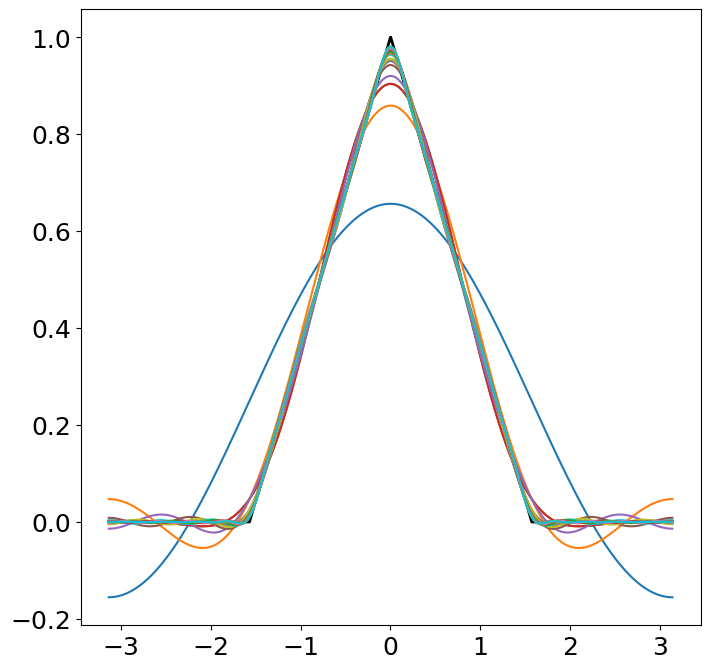

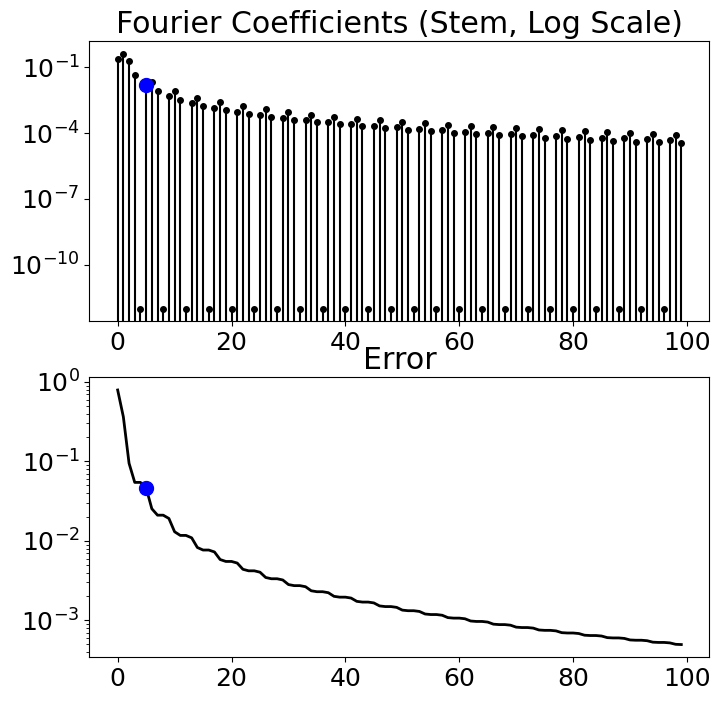

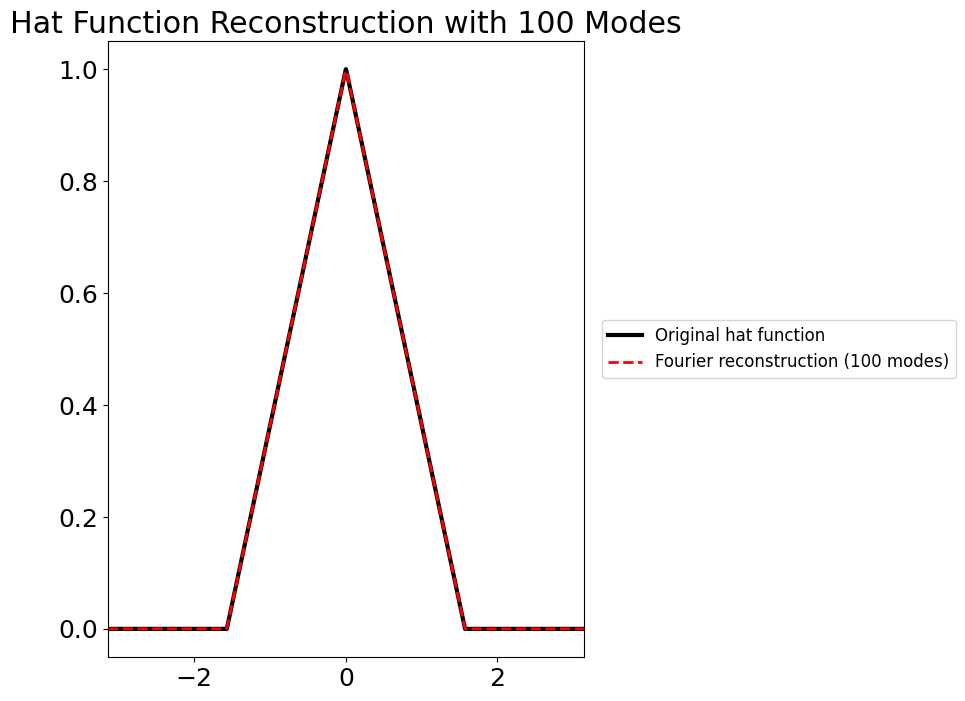

In [9]:


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

plt.rcParams['figure.figsize'] = [8, 8]
plt.rcParams.update({'font.size': 18})

# Define domain
normalized_delta_x = 0.001
L = np.pi
x = L * np.arange(-1+normalized_delta_x,1+normalized_delta_x,normalized_delta_x)
n = len(x)
nquart = int(np.floor(n/4))

# Define hat function
f = np.zeros_like(x)
f[nquart:2*nquart] = (4/n)*np.arange(1,nquart+1)
f[2*nquart:3*nquart] = np.ones(nquart) - (4/n)*np.arange(0,nquart)

fig, ax = plt.subplots()
ax.plot(x,f,'-',color='k',linewidth=2)

# Compute Fourier series
name = "Accent"
cmap = get_cmap('tab10')
colors = cmap.colors
ax.set_prop_cycle(color=colors)

A0 = np.sum(f * np.ones_like(x)) * normalized_delta_x
fFS = A0/2

A = np.zeros(20)
B = np.zeros(20)
for k in range(20):
    A[k] = np.sum(f * np.cos(np.pi*(k+1)*x/L)) * normalized_delta_x # Inner product
    B[k] = np.sum(f * np.sin(np.pi*(k+1)*x/L)) * normalized_delta_x
    fFS = fFS + A[k]*np.cos((k+1)*np.pi*x/L) + B[k]*np.sin((k+1)*np.pi*x/L)
    ax.plot(x,fFS,'-')

## Plot amplitudes

fFS = (A0/2) * np.ones_like(f)
kmax = 100
A = np.zeros(kmax)
B = np.zeros(kmax)
ERR = np.zeros(kmax)

A[0] = A0/2
ERR[0] = np.linalg.norm(f-fFS)/np.linalg.norm(f)

for k in range(1,kmax):
    A[k] = np.sum(f * np.cos(np.pi*k*x/L)) * normalized_delta_x
    B[k] = np.sum(f * np.sin(np.pi*k*x/L)) * normalized_delta_x
    fFS = fFS + A[k] * np.cos(k*np.pi*x/L) + B[k] * np.sin(k*np.pi*x/L)
    ERR[k] = np.linalg.norm(f-fFS)/np.linalg.norm(f)
    
thresh = np.median(ERR) * np.sqrt(kmax) * (4/np.sqrt(3))
r = np.max(np.where(ERR > thresh))

# Remove tiny floating-point noise in Fourier coefficients
tol = 1e-12
A_clean = A.copy()
A_clean[np.abs(A_clean) < tol] = 0.0
A_plot = np.abs(A_clean)
A_plot_log = np.where(A_plot == 0.0, tol, A_plot)

fig, axs = plt.subplots(2,1)
markerline, stemlines, baseline = axs[0].stem(np.arange(kmax), A_plot_log, linefmt='k-', markerfmt='ko', basefmt=' ')
plt.setp(stemlines, linewidth=1.5)
plt.setp(markerline, markersize=4)
axs[0].set_yscale('log')
axs[0].plot(r, A_plot_log[r], 'o', color='b', markersize=10)
plt.sca(axs[0])
plt.title('Fourier Coefficients (Stem, Log Scale)')

axs[1].semilogy(np.arange(kmax),ERR,color='k',linewidth=2)
axs[1].semilogy(r,ERR[r],'o',color='b',markersize=10)
plt.sca(axs[1])
plt.title('Error')

fig2, ax2 = plt.subplots()
ax2.plot(x, f, color='k', linewidth=3, label='Original hat function')
ax2.plot(x, fFS, '--', color='r', linewidth=2, label='Fourier reconstruction (100 modes)')
ax2.set_title('Hat Function Reconstruction with 100 Modes')
ax2.set_xlim([-L, L])
ax2.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=12)
fig2.subplots_adjust(right=0.72)

plt.show()

 



## Exponential Fourier Series (Complex Form)

For a $2L$-periodic complex-valued function $f(x)$:

$$
f(x) \sim \sum_{n=-\infty}^{\infty} c_n e^{i n \pi x / L}
$$

$$
c_n = \frac{1}{2L}\int_{-L}^{L} f(x)\, e^{-i n \pi x / L}\,dx
$$

For real-valued $f$, the coefficients have conjugate symmetry:

$$
c_{-n} = \overline{c_n}
$$

Complex inner product form:

$$
\langle u,v\rangle = \int_{-L}^{L} u(x)\,\overline{v(x)}\,dx
$$

This is why the coefficient formula uses $e^{-i n \pi x/L}$ in the projection.

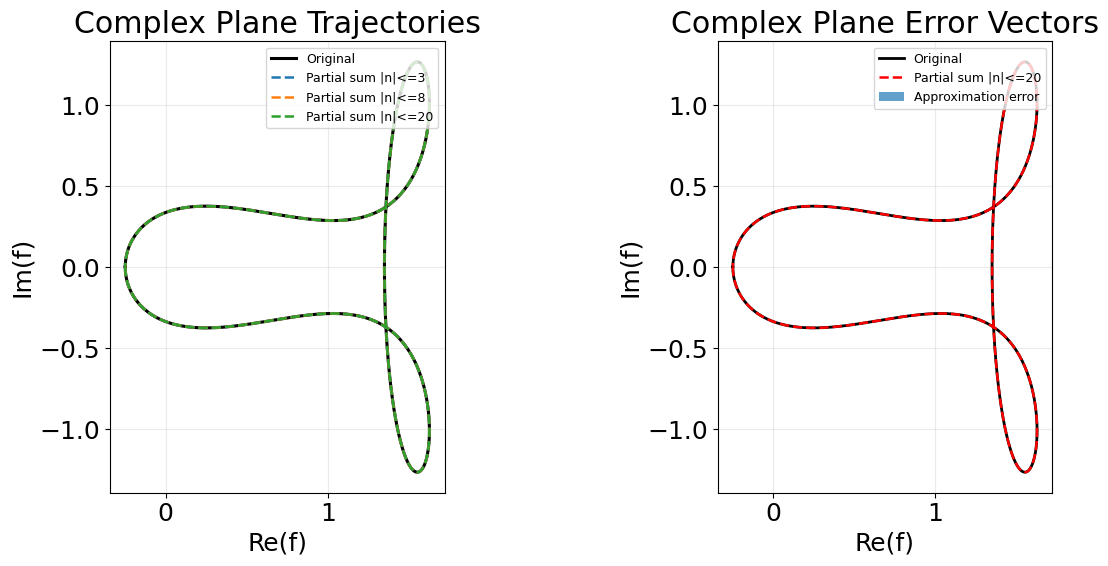

In [12]:
# Example: complex-valued periodic function and its Fourier series approximation
L = np.pi
x_c = np.linspace(-L, L, 2000, endpoint=False)
dx_c = x_c[1] - x_c[0]

# Complex signal with known harmonic content
f_complex = 1.0 + 0.8*np.exp(1j*x_c) - 0.45*np.exp(-2j*x_c) + 0.35j*np.sin(3*x_c)

# Compute exponential Fourier coefficients c_n for n in [-N, N]
N = 20
n_modes = np.arange(-N, N+1)
c = np.zeros(len(n_modes), dtype=complex)
for i, n_mode in enumerate(n_modes):
    c[i] = (1/(2*L)) * np.sum(f_complex * np.exp(-1j*n_mode*np.pi*x_c/L)) * dx_c

# Partial sums to compare convergence
partial_mode_counts = [3, 8, 20]
reconstructions = {}
for M in partial_mode_counts:
    f_hat = np.zeros_like(f_complex, dtype=complex)
    for i, n_mode in enumerate(n_modes):
        if abs(n_mode) <= M:
            f_hat += c[i] * np.exp(1j*n_mode*np.pi*x_c/L)
    reconstructions[M] = f_hat

# Plot directly in the complex plane (Re vs Im)
fig, axs = plt.subplots(1, 2, figsize=(13, 6))

# Left: trajectory comparison in complex plane
axs[0].plot(np.real(f_complex), np.imag(f_complex), color='k', linewidth=2.2, label='Original')
for M in partial_mode_counts:
    axs[0].plot(
        np.real(reconstructions[M]),
        np.imag(reconstructions[M]),
        '--',
        linewidth=1.8,
        label=f'Partial sum |n|<={M}'
    )
axs[0].set_title('Complex Plane Trajectories')
axs[0].set_xlabel('Re(f)')
axs[0].set_ylabel('Im(f)')
axs[0].set_aspect('equal', adjustable='box')
axs[0].grid(alpha=0.25)
axs[0].legend(loc='upper right', fontsize=9)

# Right: pointwise complex-plane error vectors for the highest mode count
f_best = reconstructions[partial_mode_counts[-1]]
skip = 120  # keep arrows readable
axs[1].plot(np.real(f_complex), np.imag(f_complex), color='k', linewidth=2, label='Original')
axs[1].plot(np.real(f_best), np.imag(f_best), '--', color='r', linewidth=1.8, label=f'Partial sum |n|<={partial_mode_counts[-1]}')
axs[1].quiver(
    np.real(f_best[::skip]),
    np.imag(f_best[::skip]),
    np.real(f_complex[::skip] - f_best[::skip]),
    np.imag(f_complex[::skip] - f_best[::skip]),
    angles='xy',
    scale_units='xy',
    scale=1,
    width=0.003,
    color='tab:blue',
    alpha=0.7,
    label='Approximation error'
)
axs[1].set_title('Complex Plane Error Vectors')
axs[1].set_xlabel('Re(f)')
axs[1].set_ylabel('Im(f)')
axs[1].set_aspect('equal', adjustable='box')
axs[1].grid(alpha=0.25)
axs[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()